<style>
body {
    font-family: "Microsoft YaHei", sans-serif;
    font-size: 15px;
    line-height: 1.6;
    color: #333;
}
h1 {
    color: #2c3e50;
    border-bottom: 2px solid #3498db;
    padding-bottom: 8px;
}
h2 {
    color: #3498db;
    border-left: 4px solid #3498db;
    padding-left: 10px;
}
pre {
    background: #f8f9fa;
    padding: 10px;
    border-radius: 5px;
}
</style>

# 威斯康星乳腺癌数据集分类 - ANN人工神经网络
课程大作业

基于人工神经网络（ANN）的乳腺癌分类实验报告
作者：宋禾丰 日期：2026-06-09
环境：Python + PyTorch + Jupyter Notebook

本实验使用乳腺癌数据集构建人工神经网络（ANN），完成二分类任务，并对模型训练过程、特征分布、模型性能、特征贡献度进行多维度可视化分析与评价。

## 目录
1. 环境与依赖库导入
2. 数据加载与预处理
3. 数据集划分与标准化
4. 特征相关性可视化（热力图）
5. 神经网络模型构建
6. 模型训练
7. 模型预测与综合性能评价
8. 模型结果可视化（混淆矩阵、损失曲线）
9. 模型综合性能分析（ROC曲线、P-R曲线）
10. 模型可解释性分析（SHAP特征图/船形图）
11. 结论与总结

## 1. 环境与依赖库导入
导入数据处理、绘图、深度学习框架、模型评估及模型解释所需第三方库，配置Matplotlib解决中文乱码问题。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 设置中文显示（可选，防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 数据加载与预处理
读取乳腺癌数据集，进行标签映射、缺失值检查与特征筛选，为后续建模做准备。

In [2]:

df = pd.read_csv(r"D:\data.csv")
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.iloc[:, 2:32].values
y = df["diagnosis"].values

print("数据集形状：", df.shape)
print("标签分布：\n", df["diagnosis"].value_counts())

数据集形状： (569, 33)
标签分布：
 diagnosis
0    357
1    212
Name: count, dtype: int64


## 3. 数据集划分与标准化
将数据按 8:2 划分为训练集/测试集，并对特征做标准化处理，提升神经网络收敛速度与稳定性。

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 转PyTorch张量
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## 4. 特征相关性可视化（热力图）
对数据集所有特征计算相关系数并绘制热力图，分析特征间关联程度与冗余性，辅助后续特征分析工作。

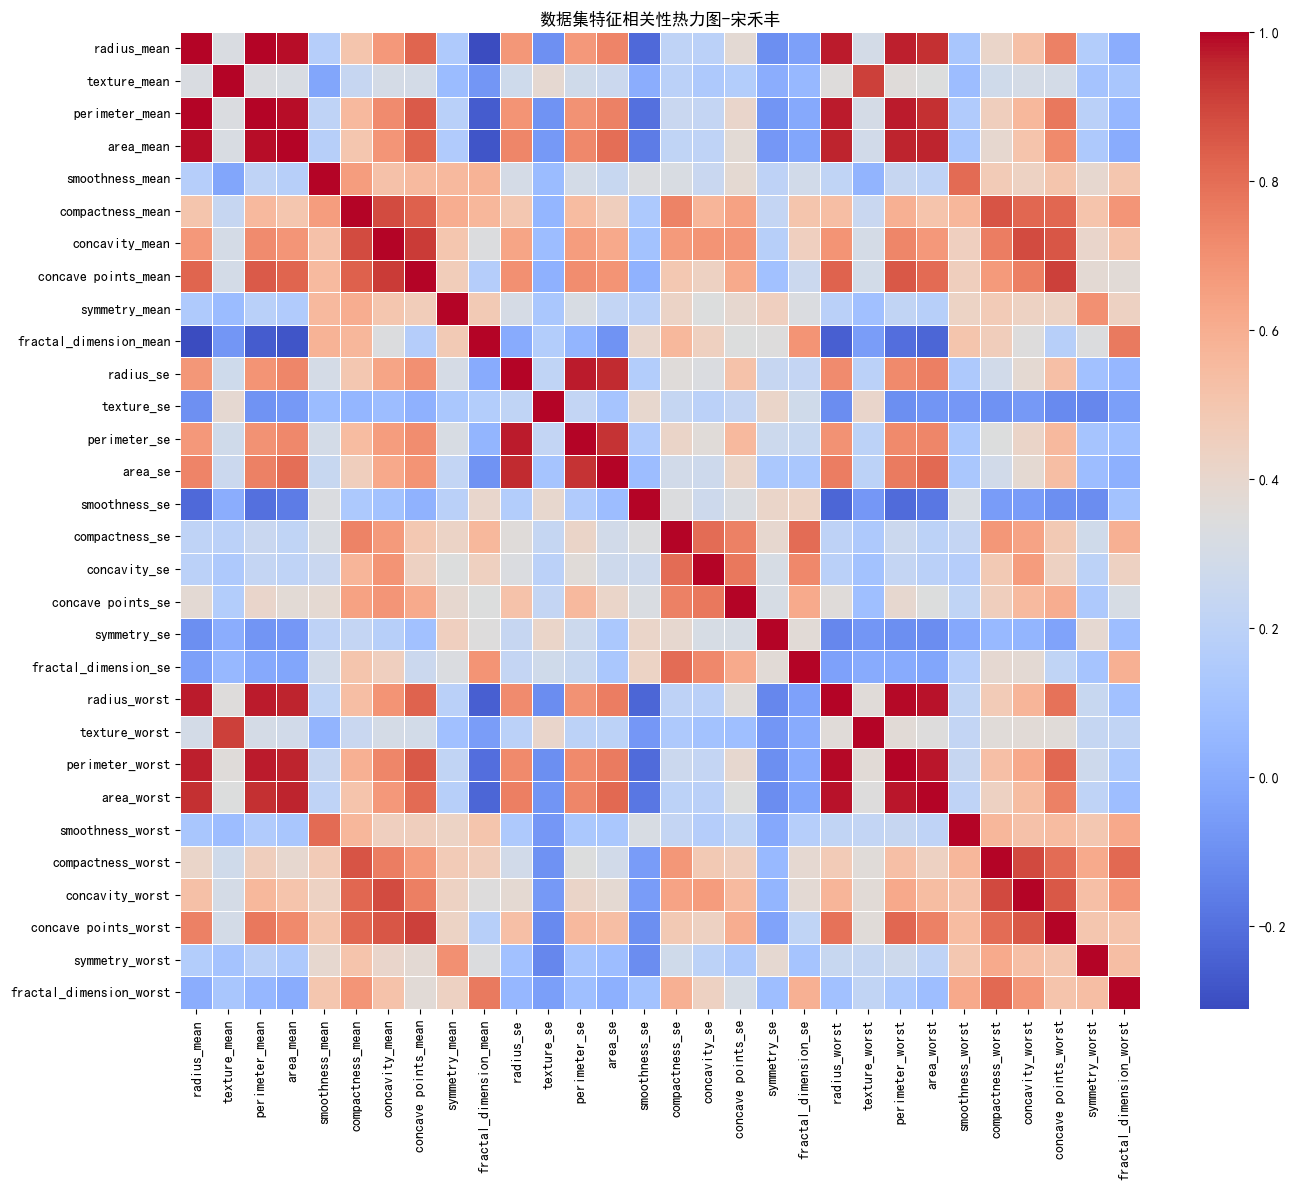

In [4]:
# 提取特征数据
feature_df = df.iloc[:, 2:32]
# 计算特征相关系数矩阵
corr = feature_df.corr()

# 绘制特征相关性热力图
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("数据集特征相关性热力图-宋禾丰")
plt.tight_layout()
plt.show()

# 保存特征名称，用于后续SHAP可视化
feature_names = df.columns[2:32].tolist()

## 5. 神经网络模型构建
搭建一个 3 层全连接人工神经网络（ANN）：
输入层（30维特征）→ 隐藏层1（16神经元）→ 隐藏层2（8神经元）→ 输出层（1神经元，sigmoid二分类）

In [5]:
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

model = ANN(input_size=30)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 6. 模型训练
设置总迭代轮数为100轮，基于训练集执行迭代训练。完成前向传播、损失计算、反向传播与参数更新，同步记录每一轮训练损失，每10轮打印一次训练日志。

In [6]:
epochs = 100
train_losses = []

print("开始训练...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

开始训练...
Epoch [10/100], Loss: 0.7152
Epoch [20/100], Loss: 0.6894
Epoch [30/100], Loss: 0.6618
Epoch [40/100], Loss: 0.6316
Epoch [50/100], Loss: 0.5949
Epoch [60/100], Loss: 0.5505
Epoch [70/100], Loss: 0.5021
Epoch [80/100], Loss: 0.4505
Epoch [90/100], Loss: 0.3977
Epoch [100/100], Loss: 0.3456


## 7. 模型预测与综合性能评价
在测试集上完成模型推理，计算整体分类准确率，并输出精确率、召回率、F1分数等多项评价指标，从多维度衡量模型分类性能。

In [7]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    y_pred_class = (y_pred_test > 0.5).float()

acc = accuracy_score(y_test, y_pred_class)
print(f"测试集准确率：{acc:.4f}")

print("\n分类报告：")
print(classification_report(y_test, y_pred_class, target_names=["良性", "恶性"]))

测试集准确率：0.9386

分类报告：
              precision    recall  f1-score   support

          良性       0.97      0.93      0.95        72
          恶性       0.89      0.95      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## 8. 模型结果可视化（混淆矩阵、损失曲线）
分别绘制混淆矩阵与训练损失曲线：混淆矩阵直观展示样本预测正误情况；损失曲线反映模型训练收敛趋势。

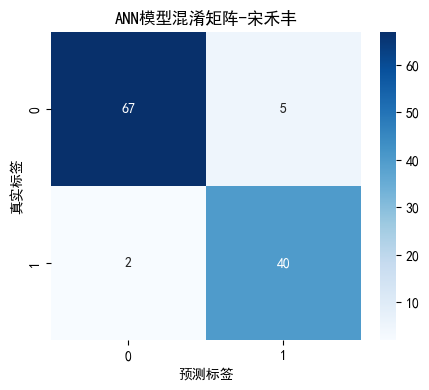

In [8]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ANN模型混淆矩阵-宋禾丰")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.show()



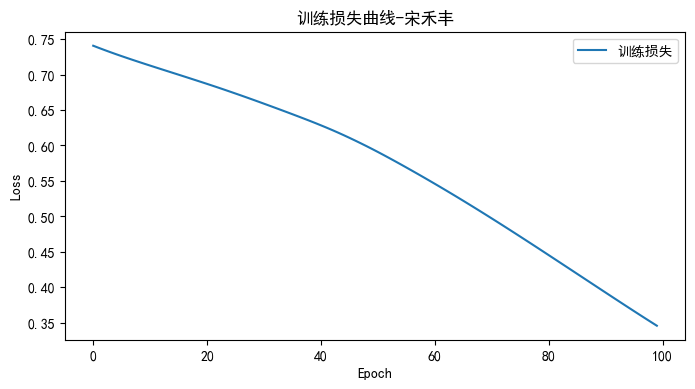

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="训练损失")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("训练损失曲线-宋禾丰")
plt.legend()
plt.show()

## 9. 模型可解释性分析（SHAP特征图/船形图）
使用SHAP算法对人工神经网络进行可解释性分析，绘制SHAP蜂群图（船形图）与特征重要性条形图，量化每个特征对分类结果的贡献大小与影响方向。

  0%|          | 0/50 [00:00<?, ?it/s]

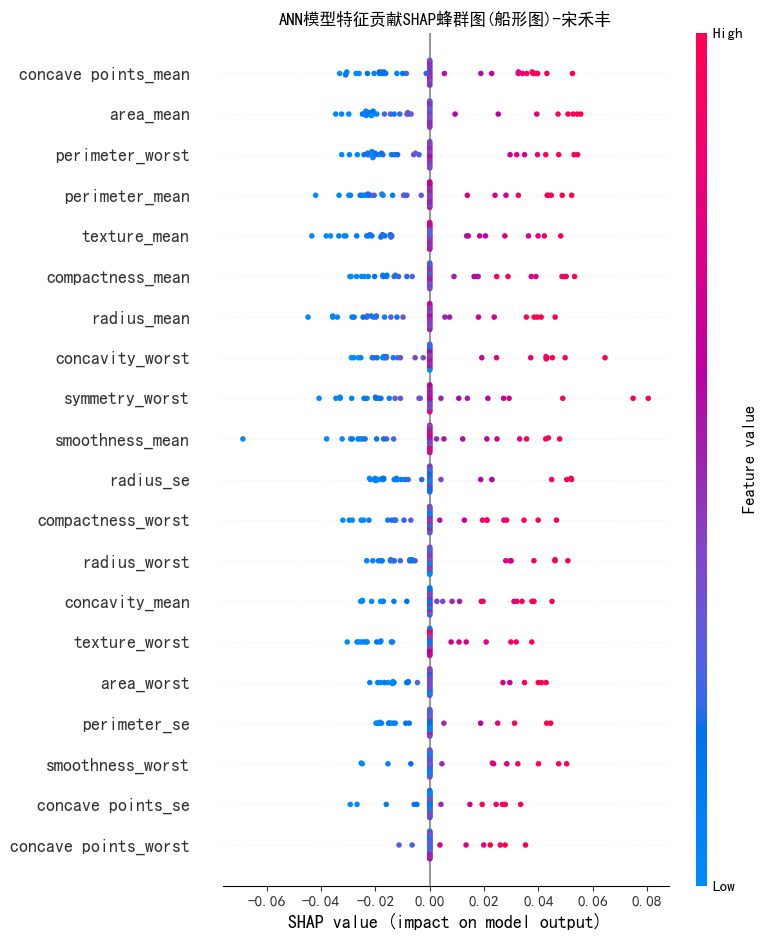

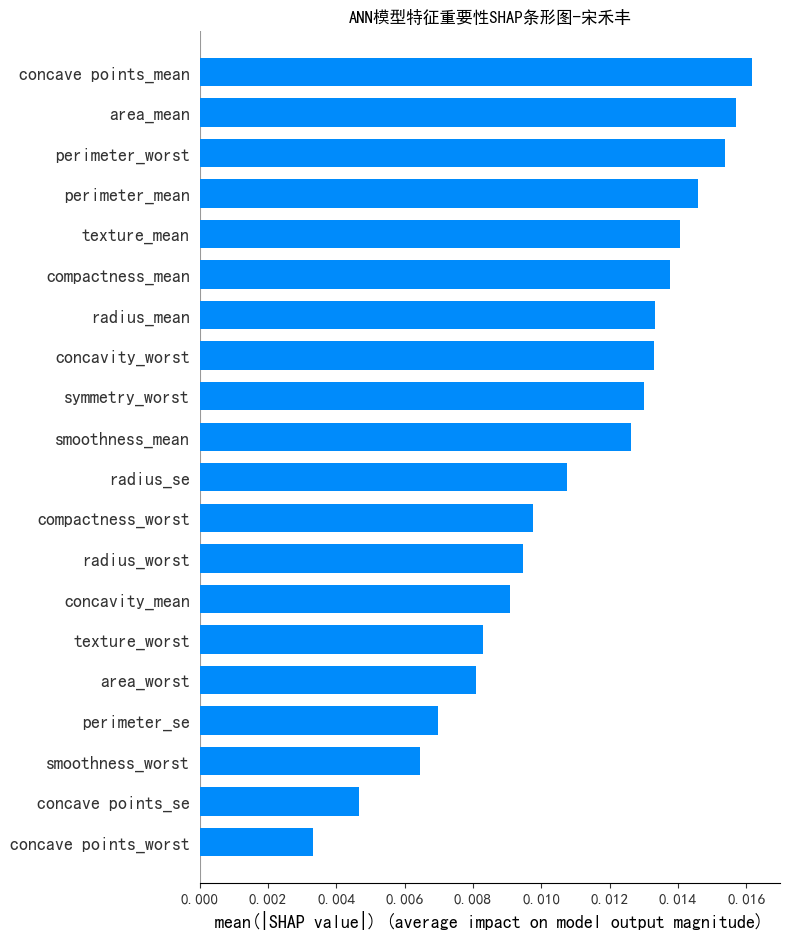

In [10]:
# 封装模型预测接口，适配SHAP计算格式
def model_predict(data):
    data_tensor = torch.tensor(data, dtype=torch.float32)
    with torch.no_grad():
        output = model(data_tensor)
    return output.numpy()

# 选取部分样本，加快计算速度
background = X_train.numpy()[:100]
test_samples = X_test.numpy()[:50]

# 初始化SHAP解释器并计算特征贡献值
explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(test_samples)

# 绘制SHAP蜂群图（船形图）
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values.reshape(-1, 30), test_samples, feature_names=feature_names, show=False)
plt.title("ANN模型特征贡献SHAP蜂群图(船形图)-宋禾丰")
plt.tight_layout()
plt.show()

# 绘制SHAP特征重要性条形图
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values.reshape(-1, 30), test_samples, feature_names=feature_names, plot_type="bar", show=False)
plt.title("ANN模型特征重要性SHAP条形图-宋禾丰")
plt.tight_layout()
plt.show()

## 10. 模型综合性能分析（ROC曲线、P-R曲线）
绘制ROC曲线并计算AUC值、绘制精确率-召回率（P-R）曲线，从不同维度量化评估模型二分类性能，直观反映模型区分正负样本的能力。

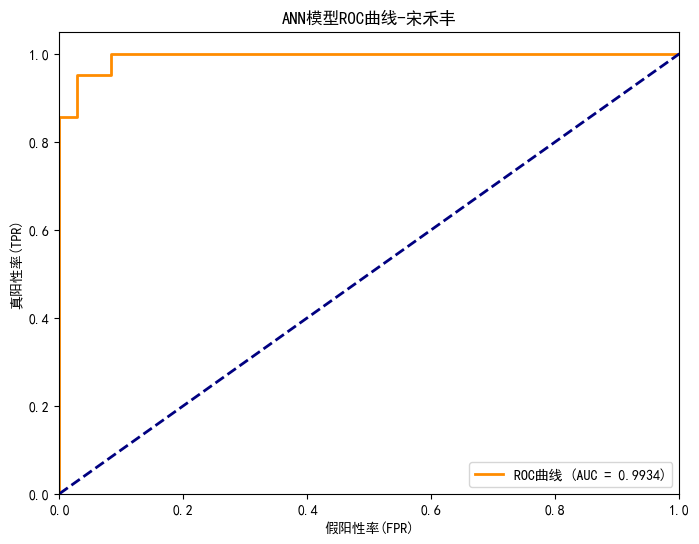

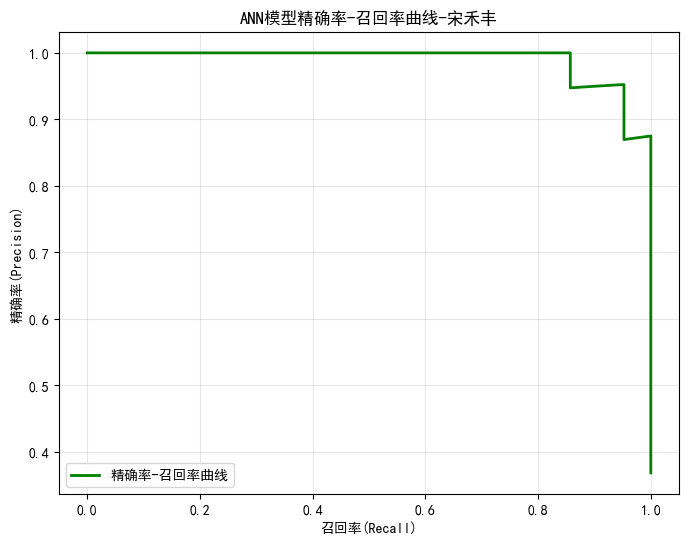

In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 转换格式，用于指标计算
y_true = y_test.numpy().ravel()
y_score = y_pred_test.numpy().ravel()

# ========== 1. ROC 曲线 + AUC ==========
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率(FPR)')
plt.ylabel('真阳性率(TPR)')
plt.title('ANN模型ROC曲线-宋禾丰')
plt.legend(loc="lower right")
plt.show()

# ========== 2. 精确率-召回率(P-R) 曲线 ==========
precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='精确率-召回率曲线')
plt.xlabel('召回率(Recall)')
plt.ylabel('精确率(Precision)')
plt.title('ANN模型精确率-召回率曲线-宋禾丰')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

## 11. 结论与总结
本实验基于PyTorch搭建三层全连接人工神经网络，完成威斯康星乳腺癌数据集良恶性二分类任务。实验完成数据读取、标签映射、数据集划分与特征标准化等预处理工作；通过100轮迭代完成模型训练，损失值持续平稳下降，模型收敛状态正常。

模型在测试集上取得93.86%的分类准确率，结合分类报告、混淆矩阵可以看出，模型对良性、恶性肿瘤均具备较好的识别能力。特征相关性热力图可直观分析特征之间的关联与冗余情况；ROC曲线AUC值接近1，证明模型整体样本区分能力优秀；精确率-召回率曲线走势平稳，说明模型在正负样本上分类表现稳定。借助SHAP可视化图表（船形图）实现黑箱模型解释，明确了各特征对分类结果的影响权重与作用方向。

综合来看，本次搭建的ANN模型整体性能良好，满足乳腺肿瘤辅助分类需求。模型仍存在少量恶性样本漏判问题，后续可通过数据增强、正则化、超参数调优、特征筛选等方式进一步优化模型泛化能力与分类精度。